# Módulo 08 — M3 — ConvLSTM U-Net

**Proyecto:** `Barranquilla_LST_2013_2026_Modeling`  
**Notebook:** `08C_train_M3_convlstm_unet.ipynb`  
**Modelo:** `M3_ConvLSTM_UNet`  

Este notebook entrena **un solo modelo** para evitar saturación de RAM en Colab. La versión `v5_2016_2025_dirfix` imprime `R²` y `bias` en entrenamiento/validación y exporta `R²` final para train, validation y test.

## Diseño

- M1–M4 usan `T3_full` con 18 canales espectrales.
- El modelo Final usa `M6A_direct_T3_spectral_delta_ssrd_delta_precip` con 20 canales: 18 espectrales + 2 climáticos.
- La comparación final se realiza en `08F_compare_models.ipynb` leyendo los CSV exportados.

## Ejecución recomendada

Use GPU T4. Si los patches no están en la ruta estándar, defina antes de ejecutar:

```python
import os
os.environ["PATCH_ROOT"] = "/content/drive/MyDrive/.../06_model_inputs/patches"
```


**Corrección v5:** crea explícitamente las subcarpetas de salida antes de cualquier exportación y usa lectura segura de archivos NPZ para evitar errores de sincronización de Google Drive.

In [1]:

# ============================================================
# CELDA 1 — Imports, entorno y configuración reproducible
# ============================================================

from pathlib import Path
from dataclasses import dataclass, asdict
import json
import math
import os
import random
import warnings
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

# Google Drive: no forzar montaje si ya está disponible.
if Path("/content").exists() and not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Advertencia: no fue posible montar Google Drive automáticamente.")
        print("Detalle:", e)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


@dataclass
class Config:
    """Configuración del entrenamiento individual del Módulo 08.

    Para reproducibilidad, el notebook permite fijar PATCH_ROOT mediante variable
    de entorno antes de ejecutar:

    os.environ["PATCH_ROOT"] = "/content/drive/MyDrive/.../06_model_inputs/patches"

    Este notebook entrena un único modelo. La comparación se realiza después en
    08F_compare_models.ipynb leyendo los CSV exportados.
    """

    project_root: str = os.environ.get(
        "PROJECT_ROOT",
        "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling"
    )
    patch_root_override: str = os.environ.get("PATCH_ROOT", "")

    model_key: str = "M3_ConvLSTM_UNet"
    patch_folder: str = "T3_full"
    dataset_mode: str = "spectral18"  # spectral18 | full
    model_description: str = "Modelo 3: ConvLSTM U-Net con T3_full espectral."

    # Canales T3 espectrales: 3 años previos x 6 variables.
    spectral_channels: int = 18
    spectral_steps: int = 3
    spectral_features_per_step: int = 6

    # Entrenamiento. Valores conservadores para Colab/T4.
    batch_size: int = 4
    num_workers: int = 0
    pin_memory: bool = False
    max_epochs: int = 100
    patience: int = 15
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    huber_delta: float = 1.0
    grad_clip_norm: float = 1.0

    # Periodo operativo de modelación.
    # El documento metodológico del repositorio define target years 2016–2025
    # y excluye 2026 por no representar un periodo anual completo.
    target_year_min: int = 2016
    target_year_max: int = 2025

    # Debug controlado.
    fast_debug: bool = False
    fast_debug_epochs: int = 2
    fast_debug_batches: int = 3

    # Arquitectura.
    base_channels: int = 32
    convlstm_hidden_channels: int = 32
    dropout: float = 0.10

    # Salidas.
    output_subdir: str = "07_models/t3_climate/module08_independent_2016_2025/M3_ConvLSTM_UNet"


CFG = Config()


def candidate_roots_from_drive() -> List[Path]:
    roots = []
    roots.append(Path.cwd())
    if Path("/content/drive/MyDrive").exists():
        mydrive = Path("/content/drive/MyDrive")
        roots.extend([
            mydrive / "Barranquilla_LST_2013_2026_Modeling",
            mydrive / "Barranquilla_LST_2013_2026_Modeling-main",
            mydrive / "Barranquilla_LST_2013_2026_Modeling_v2",
        ])
    roots.append(Path(CFG.project_root))
    return list(dict.fromkeys(roots))


def find_patch_root(cfg: Config) -> Tuple[Path, Path]:
    if cfg.patch_root_override.strip():
        patch_root = Path(cfg.patch_root_override).expanduser()
        if not patch_root.exists():
            raise FileNotFoundError(f"PATCH_ROOT definido pero inexistente: {patch_root}")
        project_root = patch_root.parent.parent
        return project_root, patch_root

    checked = []
    for root in candidate_roots_from_drive():
        patch_root = root / "06_model_inputs" / "patches"
        checked.append(patch_root)
        if patch_root.exists():
            return root, patch_root

    # Búsqueda acotada para Drive cuando la carpeta está en una ubicación distinta.
    search_bases = [Path("/content/drive/MyDrive"), Path("/content/drive/Shareddrives"), Path.cwd()]
    for base in search_bases:
        if not base.exists():
            continue
        for dirpath, dirnames, filenames in os.walk(base):
            p = Path(dirpath)
            if ".Trash" in p.parts or ".ipynb_checkpoints" in p.parts:
                continue
            try:
                rel_depth = len(p.relative_to(base).parts)
            except Exception:
                rel_depth = 0
            if rel_depth > 6:
                dirnames[:] = []
                continue
            if p.name == "patches" and (p / cfg.patch_folder).exists():
                return p.parent.parent, p

    print("\nNo se encontró 06_model_inputs/patches.")
    print("Rutas evaluadas:")
    for p in checked:
        print(" -", p, "| existe:", p.exists())
    print("\nDefina manualmente PATCH_ROOT con la ruta real de la carpeta 'patches'.")
    print("Ejemplo:")
    print("os.environ['PATCH_ROOT'] = '/content/drive/MyDrive/.../06_model_inputs/patches'")
    raise FileNotFoundError("No se pudo resolver PATCH_ROOT.")


PROJECT_ROOT, PATCH_ROOT = find_patch_root(CFG)
OUTPUT_DIR = PROJECT_ROOT / CFG.output_subdir


def ensure_output_dirs(output_dir: Path) -> None:
    """Create all output folders required by this notebook before any write operation."""
    output_dir.mkdir(parents=True, exist_ok=True)
    for sub in ["checkpoints", "history", "evaluation", "figures", "metadata", "logs"]:
        (output_dir / sub).mkdir(parents=True, exist_ok=True)


ensure_output_dirs(OUTPUT_DIR)

config_path = OUTPUT_DIR / "metadata" / f"08_config_{CFG.model_key}.json"
config_path.parent.mkdir(parents=True, exist_ok=True)
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2, ensure_ascii=False)

print("MODEL_KEY   :", CFG.model_key)
print("DESCRIPTION :", CFG.model_description)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PATCH_ROOT  :", PATCH_ROOT)
print("OUTPUT_DIR  :", OUTPUT_DIR)
print("DEVICE      :", DEVICE)
print("\nCarpetas visibles en PATCH_ROOT:")
for p in sorted(PATCH_ROOT.iterdir()):
    if p.is_dir():
        print(" -", p.name)


Mounted at /content/drive
DEVICE: cuda
GPU: Tesla T4
MODEL_KEY   : M3_ConvLSTM_UNet
DESCRIPTION : Modelo 3: ConvLSTM U-Net con T3_full espectral.
PROJECT_ROOT: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling
PATCH_ROOT  : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches
OUTPUT_DIR  : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M3_ConvLSTM_UNet
DEVICE      : cuda

Carpetas visibles en PATCH_ROOT:
 - M5B_reduced_spectral_SAVI_UI_NDMI_BSI_delta_t2m_delta_radiation_T3manifest
 - M6A_direct_T3_spectral_delta_ssrd_delta_precip
 - M6A_direct_T3_spectral_delta_ssrd_delta_precip_T3manifest
 - M6B_residual_m5b_pred_delta_ssrd_delta_precip
 - T3_full
 - T3_full_M5A_delta_t2m
 - T3_full_M5B_delta_t2m_delta_radiation
 - T3_full_M5C_delta_t2m_delta_radiation_delta_rh2m
 - T3_full_M5D_delta_t2m_delta_radiation_delta_precip
 - T3_spectral_climate_nasa_power


In [2]:

# ============================================================
# CELDA 2 — Inventario reproducible de patches
# ============================================================

def list_npz_files(folder: Path) -> List[Path]:
    candidates = []
    for d in [folder / "npz", folder]:
        if d.exists():
            candidates.extend(sorted(d.glob("*.npz")))
    return sorted(set(candidates))


def inspect_npz_example(npz_path: Path) -> Dict:
    """Inspect one NPZ file without keeping open handles on Google Drive."""
    out = {
        "example_file": npz_path.name,
        "keys": None,
        "x_shape": None,
        "n_channels_detected": None,
        "channel_axis": None,
        "channel_names": None
    }
    try:
        with np.load(npz_path, allow_pickle=True) as data:
            keys = list(data.keys())
            out["keys"] = keys

            x_key = next((k for k in ["X", "x", "inputs", "features"] if k in keys), None)
            X = None
            if x_key is not None:
                # Only read array metadata/shape here. The array itself is not retained.
                X = data[x_key]
                out["x_shape"] = tuple(X.shape)

            ch_names = None
            if "channel_names" in keys:
                ch_raw = data["channel_names"]
                ch_names = [str(v) for v in ch_raw.tolist()]
                out["channel_names"] = ch_names

            if x_key is not None and X is not None and X.ndim == 4:
                if ch_names is not None:
                    n_ch = len(ch_names)
                    if X.shape[1] == n_ch:
                        out["n_channels_detected"] = n_ch
                        out["channel_axis"] = 1
                    elif X.shape[-1] == n_ch:
                        out["n_channels_detected"] = n_ch
                        out["channel_axis"] = -1
                    else:
                        out["n_channels_detected"] = None
                        out["channel_axis"] = None
                else:
                    # Project-specific heuristic: patches are 128 x 128; channels are axis 1 or last axis.
                    if X.shape[1] <= 64 and X.shape[-1] == 128:
                        out["n_channels_detected"] = X.shape[1]
                        out["channel_axis"] = 1
                    elif X.shape[-1] <= 64 and X.shape[1] == 128:
                        out["n_channels_detected"] = X.shape[-1]
                        out["channel_axis"] = -1
    except Exception as e:
        out["keys"] = f"ERROR: {repr(e)}"
    return out

records = []

if not PATCH_ROOT.exists():
    raise FileNotFoundError(f"No existe PATCH_ROOT: {PATCH_ROOT}")

for folder in sorted(PATCH_ROOT.iterdir()):
    if not folder.is_dir():
        continue

    npz_files = list_npz_files(folder)
    rec = {
        "folder": folder.name,
        "npz_dir": str(npz_files[0].parent) if npz_files else None,
        "n_npz": len(npz_files),
        "has_train": any("train" in f.name.lower() for f in npz_files),
        "has_validation": any(("validation" in f.name.lower()) or ("val" in f.name.lower()) for f in npz_files),
        "has_test": any("test" in f.name.lower() for f in npz_files),
    }
    if npz_files:
        rec.update(inspect_npz_example(npz_files[0]))
    records.append(rec)

inventory = pd.DataFrame(records)
display(inventory[[
    "folder", "n_npz", "has_train", "has_validation", "has_test",
    "example_file", "x_shape", "n_channels_detected", "channel_axis"
]])

ensure_output_dirs(OUTPUT_DIR)
inventory_csv = OUTPUT_DIR / "metadata" / "08_patch_inventory_corrected.csv"
inventory_csv.parent.mkdir(parents=True, exist_ok=True)
inventory.to_csv(inventory_csv, index=False)
print("Inventario guardado en:", inventory_csv)


,folder,n_npz,has_train,has_validation,has_test,example_file,x_shape,n_channels_detected,channel_axis
0,M5B_reduced_spectral_SAVI_UI_NDMI_BSI_delta_t2...,3,True,True,True,M5B_reduced_spectral_SAVI_UI_NDMI_BSI_delta_t2...,"(165, 128, 128, 14)",14,-1
1,M6A_direct_T3_spectral_delta_ssrd_delta_precip,3,True,True,True,M6A_direct_T3_spectral_delta_ssrd_delta_precip...,"(780, 128, 128, 20)",20,-1
2,M6A_direct_T3_spectral_delta_ssrd_delta_precip...,3,True,True,True,M6A_direct_T3_spectral_delta_ssrd_delta_precip...,"(165, 128, 128, 20)",20,-1
3,M6B_residual_m5b_pred_delta_ssrd_delta_precip,3,True,True,True,M6B_residual_m5b_pred_delta_ssrd_delta_precip_...,"(780, 128, 128, 3)",3,-1
4,T3_full,14,True,True,True,T3_full_patches_target_2016_train.npz,"(207, 128, 128, 18)",18,-1
5,T3_full_M5A_delta_t2m,4,True,True,True,T3_full_M5A_delta_t2m_patches_all_splits.npz,"(1155, 128, 128, 19)",19,-1
6,T3_full_M5B_delta_t2m_delta_radiation,4,True,True,True,T3_full_M5B_delta_t2m_delta_radiation_patches_...,"(1155, 128, 128, 20)",20,-1
7,T3_full_M5C_delta_t2m_delta_radiation_delta_rh2m,4,True,True,True,T3_full_M5C_delta_t2m_delta_radiation_delta_rh...,"(1155, 128, 128, 21)",21,-1
8,T3_full_M5D_delta_t2m_delta_radiation_delta_pr...,4,True,True,True,T3_full_M5D_delta_t2m_delta_radiation_delta_pr...,"(1155, 128, 128, 21)",21,-1
9,T3_spectral_climate_nasa_power,13,True,True,True,T3_Climate_patches_target_2016_train.npz,"(207, 128, 128, 20)",20,-1


Inventario guardado en: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M3_ConvLSTM_UNet/metadata/08_patch_inventory_corrected.csv


In [3]:

# ============================================================
# CELDA 3 — Resolución estricta de carpeta de entrada
# ============================================================

INPUT_DIR = PATCH_ROOT / CFG.patch_folder
print("INPUT_DIR:", INPUT_DIR)

if not INPUT_DIR.exists():
    raise FileNotFoundError(f"No existe la carpeta de entrada: {INPUT_DIR}")

input_npz = list_npz_files(INPUT_DIR)
if len(input_npz) == 0:
    raise FileNotFoundError(f"No hay archivos .npz en {INPUT_DIR}")

print("\nNPZ disponibles en la carpeta seleccionada:")
for f in input_npz:
    print(" -", f.name)

selection = {
    "model_key": CFG.model_key,
    "patch_folder": CFG.patch_folder,
    "dataset_mode": CFG.dataset_mode,
    "input_dir": str(INPUT_DIR),
    "npz_count": len(input_npz),
    "npz_files": [f.name for f in input_npz],
}

with open(OUTPUT_DIR / "metadata" / f"08_patch_selection_{CFG.model_key}.json", "w", encoding="utf-8") as f:
    json.dump(selection, f, indent=2, ensure_ascii=False)


INPUT_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_full

NPZ disponibles en la carpeta seleccionada:
 - T3_full_patches_target_2016_train.npz
 - T3_full_patches_target_2017_train.npz
 - T3_full_patches_target_2018_train.npz
 - T3_full_patches_target_2019_train.npz
 - T3_full_patches_target_2020_validation.npz
 - T3_full_patches_target_2021_validation.npz
 - T3_full_patches_target_2022_validation.npz
 - T3_full_patches_target_2023_test.npz
 - T3_full_patches_target_2024_test.npz
 - T3_full_patches_target_2025_test.npz
 - T3_full_patches_target_2026_test.npz
 - T3_full_patches_test_2016_2026.npz
 - T3_full_patches_train_2016_2026.npz
 - T3_full_patches_validation_2016_2026.npz


In [4]:

# ============================================================
# CELDA 4 — Utilidades robustas de lectura NPZ
# ============================================================

def _as_list_channel_names(raw):
    if raw is None:
        return None
    try:
        return [str(v) for v in raw.tolist()]
    except Exception:
        return [str(v) for v in list(raw)]


def detect_and_convert_X_to_nchw(X: np.ndarray, channel_names: Optional[List[str]] = None) -> np.ndarray:
    """Convierte X a formato NCHW. Soporta NHWC y NCHW."""
    if X.ndim != 4:
        raise ValueError(f"Se esperaba X 4D, pero llegó shape={X.shape}")

    n_ch_names = len(channel_names) if channel_names is not None else None

    if n_ch_names is not None:
        if X.shape[1] == n_ch_names:
            return X
        if X.shape[-1] == n_ch_names:
            return np.transpose(X, (0, 3, 1, 2))

    # Heurística de respaldo para patches 128x128
    if X.shape[1] <= 64 and X.shape[2] == X.shape[3]:
        return X
    if X.shape[-1] <= 64 and X.shape[1] == X.shape[2]:
        return np.transpose(X, (0, 3, 1, 2))

    raise ValueError(
        f"No se pudo detectar eje de canales para X shape={X.shape}. "
        "Revise channel_names o estructura del NPZ."
    )


def ensure_y_mask_nchw(y: np.ndarray, mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Asegura y y mask como N,1,H,W."""
    def fix(arr):
        arr = np.asarray(arr)
        if arr.ndim == 3:
            arr = arr[:, None, :, :]
        elif arr.ndim == 4:
            # NHWC con un canal
            if arr.shape[-1] == 1 and arr.shape[1] != 1:
                arr = np.transpose(arr, (0, 3, 1, 2))
            elif arr.shape[1] == 1:
                pass
            else:
                raise ValueError(f"y/mask 4D debe tener un canal. Shape recibido: {arr.shape}")
        else:
            raise ValueError(f"y/mask debe ser 3D o 4D. Shape recibido: {arr.shape}")
        return arr
    return fix(y), fix(mask)


def infer_target_years(data, n: int) -> np.ndarray:
    """Intenta recuperar el año objetivo. Soporta target_year, year, years."""
    keys = list(data.keys())

    if "target_year" in keys:
        arr = np.asarray(data["target_year"])
    elif "year" in keys:
        arr = np.asarray(data["year"])
    elif "years" in keys:
        arr = np.asarray(data["years"])
        # En algunos manifiestos, years puede representar los años fuente.
        # Si es 2D, se toma el último año + 1 como año objetivo cuando parece una secuencia previa.
        if arr.ndim == 2:
            arr = arr[:, -1] + 1
    else:
        arr = np.full((n,), -9999)

    if arr.ndim == 0:
        arr = np.full((n,), int(arr))
    elif arr.ndim > 1:
        arr = arr.reshape(n, -1)[:, -1]

    if len(arr) != n:
        arr = np.resize(arr, n)
    return arr.astype(int)


def infer_split_array(data, n: int, fallback_split: str) -> np.ndarray:
    """Recupera o construye el vector de split con longitud exactamente n.

    Algunos NPZ consolidados guardan la clave split como escalar o como arreglo
    de longitud 1, aunque X tenga N muestras. En ese caso se expande a N.
    Esta función evita errores al aplicar filtros booleanos por año objetivo.
    """
    keys = list(data.keys())

    if "split" not in keys:
        return np.full((n,), str(fallback_split), dtype=object)

    s = np.asarray(data["split"], dtype=object)

    if s.ndim == 0:
        return np.full((n,), str(s.item()), dtype=object)

    s = s.reshape(-1)

    if len(s) == n:
        return np.asarray([str(v) for v in s.tolist()], dtype=object)

    if len(s) == 1:
        return np.full((n,), str(s[0]), dtype=object)

    raise ValueError(
        f"La clave 'split' tiene longitud {len(s)}, pero X tiene {n} muestras. "
        "Revise la estructura del NPZ o elimine/corrija la clave split."
    )


def load_one_npz(npz_path: Path, fallback_split: str) -> Dict:
    data = np.load(npz_path, allow_pickle=True)
    keys = list(data.keys())

    if "X" not in keys:
        raise KeyError(f"{npz_path.name} no contiene clave 'X'. Claves: {keys}")
    if "y" not in keys:
        raise KeyError(f"{npz_path.name} no contiene clave 'y'. Claves: {keys}")
    if "mask" not in keys:
        raise KeyError(f"{npz_path.name} no contiene clave 'mask'. Claves: {keys}")

    channel_names = _as_list_channel_names(data["channel_names"]) if "channel_names" in keys else None

    X = detect_and_convert_X_to_nchw(np.asarray(data["X"]), channel_names)
    y, mask = ensure_y_mask_nchw(np.asarray(data["y"]), np.asarray(data["mask"]))

    n = X.shape[0]
    years = infer_target_years(data, n)
    splits = infer_split_array(data, n, fallback_split)

    out = {
        "X": X.astype(np.float32),
        "y": y.astype(np.float32),
        "mask": mask.astype(np.float32),
        "target_year": years,
        "split": splits,
        "channel_names": channel_names,
        "source_file": np.array([npz_path.name] * n)
    }
    data.close()
    return out


def find_split_npz_files(folder: Path, split: str) -> List[Path]:
    """Encuentra archivos NPZ del split sin duplicar muestras.

    Prioridad:
    1. Archivo consolidado por split, por ejemplo:
       T3_full_patches_train_2016_2026.npz
       T3_full_patches_validation_2016_2026.npz
       T3_full_patches_test_2016_2026.npz
    2. Archivos por año objetivo, por ejemplo:
       T3_full_patches_target_2016_train.npz
    3. Archivo all/all_splits si existe.

    Esta prioridad evita cargar simultáneamente los archivos por año y el
    archivo consolidado, lo cual duplicaría muestras y contaminaría métricas.
    """
    files = list_npz_files(folder)
    split_l = split.lower()

    if split_l == "validation":
        split_tokens = ["validation", "val"]
    else:
        split_tokens = [split_l]

    # 1. Consolidados: contienen el split, pero no contienen 'target'.
    consolidated = []
    for f in files:
        name = f.name.lower()
        if "target" in name:
            continue
        if any(tok in name for tok in split_tokens):
            consolidated.append(f)

    if len(consolidated) > 0:
        return sorted(set(consolidated))

    # 2. Por año objetivo.
    per_year = []
    for f in files:
        name = f.name.lower()
        if "target" in name and any(tok in name for tok in split_tokens):
            per_year.append(f)

    if len(per_year) > 0:
        return sorted(set(per_year))

    # 3. Archivo universal.
    all_files = [f for f in files if ("all_splits" in f.name.lower() or "all" in f.name.lower())]
    if len(all_files) > 0:
        return sorted(set(all_files))

    raise FileNotFoundError(f"No se encontraron NPZ para split='{split}' en {folder}")


def load_split_from_folder(folder: Path, split: str) -> Dict:
    files = find_split_npz_files(folder, split)
    chunks = []

    for f in files:
        d = load_one_npz(f, fallback_split=split)
        # Si el archivo trae varios splits, filtrar.
        split_arr = np.char.lower(d["split"].astype(str))
        if len(np.unique(split_arr)) > 1:
            if split == "validation":
                keep = np.isin(split_arr, ["validation", "val"])
            else:
                keep = split_arr == split
            if keep.sum() == 0:
                continue
            for k in ["X", "y", "mask", "target_year", "split", "source_file"]:
                d[k] = d[k][keep]
        chunks.append(d)

    if len(chunks) == 0:
        raise RuntimeError(f"No quedaron muestras para split={split} en {folder}")

    X = np.concatenate([c["X"] for c in chunks], axis=0)
    y = np.concatenate([c["y"] for c in chunks], axis=0)
    mask = np.concatenate([c["mask"] for c in chunks], axis=0)
    target_year = np.concatenate([c["target_year"] for c in chunks], axis=0)
    split_arr = np.concatenate([c["split"] for c in chunks], axis=0)
    source_file = np.concatenate([c["source_file"] for c in chunks], axis=0)

    # Usar nombres de canales del primer chunk que los tenga.
    channel_names = next((c["channel_names"] for c in chunks if c["channel_names"] is not None), None)

    # Filtro metodológico de años objetivo.
    # Mantiene la partición declarada en el documento de modelación:
    # train = 2016–2019, validation = 2020–2022, test = 2023–2025.
    # Excluye 2026 para evitar comparar modelos con ventanas temporales distintas.
    year_keep = (target_year >= CFG.target_year_min) & (target_year <= CFG.target_year_max)
    if year_keep.sum() == 0:
        raise RuntimeError(
            f"No quedaron muestras para split={split} después de filtrar "
            f"{CFG.target_year_min}–{CFG.target_year_max}."
        )

    if year_keep.sum() < len(target_year):
        dropped_years = sorted(np.unique(target_year[~year_keep]).astype(int).tolist())
        print(
            f"[INFO] {folder.name} | split={split}: se excluyeron años objetivo "
            f"fuera de {CFG.target_year_min}–{CFG.target_year_max}: {dropped_years}"
        )

    X = X[year_keep]
    y = y[year_keep]
    mask = mask[year_keep]
    target_year = target_year[year_keep]
    split_arr = split_arr[year_keep]
    source_file = source_file[year_keep]

    return {
        "X": X,
        "y": y,
        "mask": mask,
        "target_year": target_year,
        "split": split_arr,
        "channel_names": channel_names,
        "source_file": source_file,
        "folder": str(folder)
    }


In [5]:

# ============================================================
# CELDA 5 — Carga y auditoría de splits del modelo actual
# ============================================================

data_block = {
    "train": load_split_from_folder(INPUT_DIR, "train"),
    "validation": load_split_from_folder(INPUT_DIR, "validation"),
    "test": load_split_from_folder(INPUT_DIR, "test"),
}


def summarize_loaded_block(block: Dict[str, Dict], label: str) -> pd.DataFrame:
    rows = []
    for split, d in block.items():
        rows.append({
            "block": label,
            "split": split,
            "n_samples": d["X"].shape[0],
            "X_shape": d["X"].shape,
            "y_shape": d["y"].shape,
            "mask_shape": d["mask"].shape,
            "n_channels": d["X"].shape[1],
            "years_min": int(np.min(d["target_year"])) if len(d["target_year"]) else None,
            "years_max": int(np.max(d["target_year"])) if len(d["target_year"]) else None,
            "unique_years": sorted(np.unique(d["target_year"]).astype(int).tolist()),
            "n_channel_names": len(d["channel_names"]) if d["channel_names"] is not None else None,
            "source_files": sorted(np.unique(d["source_file"]).tolist()),
        })
    return pd.DataFrame(rows)

summary_df = summarize_loaded_block(data_block, CFG.model_key)
display(summary_df)
summary_df.to_csv(OUTPUT_DIR / "metadata" / f"08_loaded_patch_summary_{CFG.model_key}.csv", index=False)

n_channels = int(data_block["train"]["X"].shape[1])
print("n_channels detectados:", n_channels)

if CFG.dataset_mode == "spectral18":
    if n_channels < CFG.spectral_channels:
        raise ValueError(f"El modelo espectral requiere al menos {CFG.spectral_channels} canales; llegaron {n_channels}.")
    print("Modo espectral: se usarán los primeros 18 canales.")

if CFG.model_key == "FINAL_T3Climate_ConvLSTM_SE_UNet":
    if n_channels <= CFG.spectral_channels:
        raise ValueError(
            "El modelo FINAL requiere más de 18 canales. "
            "Revise que la carpeta seleccionada sea T3-Climate y no T3_full."
        )
    print("Modo final T3-Climate: se usarán todos los canales disponibles.")


[INFO] T3_full | split=test: se excluyeron años objetivo fuera de 2016–2025: [2026]


,block,split,n_samples,X_shape,y_shape,mask_shape,n_channels,years_min,years_max,unique_years,n_channel_names,source_files
0,M3_ConvLSTM_UNet,train,826,"(826, 18, 128, 128)","(826, 1, 128, 128)","(826, 1, 128, 128)",18,2016,2019,"[2016, 2017, 2018, 2019]",18,[T3_full_patches_train_2016_2026.npz]
1,M3_ConvLSTM_UNet,validation,164,"(164, 18, 128, 128)","(164, 1, 128, 128)","(164, 1, 128, 128)",18,2020,2022,"[2020, 2021, 2022]",18,[T3_full_patches_validation_2016_2026.npz]
2,M3_ConvLSTM_UNet,test,165,"(165, 18, 128, 128)","(165, 1, 128, 128)","(165, 1, 128, 128)",18,2023,2025,"[2023, 2024, 2025]",18,[T3_full_patches_test_2016_2026.npz]


n_channels detectados: 18
Modo espectral: se usarán los primeros 18 canales.


In [6]:

# ============================================================
# CELDA 6 — Dataset y DataLoaders del modelo actual
# ============================================================

class PatchArrayDataset(Dataset):
    def __init__(self, data: Dict, mode: str, cfg: Config):
        """
        mode:
        - 'spectral18': usa los primeros 18 canales.
        - 'full': usa todos los canales disponibles.
        """
        self.mode = mode
        self.cfg = cfg

        X = data["X"]
        if mode == "spectral18":
            X = X[:, :cfg.spectral_channels, :, :]
        elif mode == "full":
            pass
        else:
            raise ValueError(f"mode no reconocido: {mode}")

        self.X = X.astype(np.float32)
        self.y = data["y"].astype(np.float32)
        self.mask = (data["mask"] > 0).astype(np.float32)
        self.target_year = data["target_year"].astype(int)
        self.source_file = data["source_file"]
        self.channel_names = data["channel_names"]

        if self.X.shape[0] != self.y.shape[0] or self.X.shape[0] != self.mask.shape[0]:
            raise ValueError("X, y y mask tienen diferente número de muestras.")

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return {
            "X": torch.from_numpy(self.X[idx]),
            "y": torch.from_numpy(self.y[idx]),
            "mask": torch.from_numpy(self.mask[idx]),
            "target_year": torch.tensor(self.target_year[idx], dtype=torch.long),
        }


def build_loaders(data_block: Dict, mode: str, cfg: Config):
    train_ds = PatchArrayDataset(data_block["train"], mode, cfg)
    val_ds = PatchArrayDataset(data_block["validation"], mode, cfg)
    test_ds = PatchArrayDataset(data_block["test"], mode, cfg)

    loader_kwargs = dict(
        batch_size=cfg.batch_size,
        num_workers=cfg.num_workers,
        pin_memory=(cfg.pin_memory and DEVICE.type == "cuda"),
        drop_last=False
    )

    train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader


train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = build_loaders(data_block, CFG.dataset_mode, CFG)

print("Train/validation/test:", len(train_ds), len(val_ds), len(test_ds))
print("Canales usados:", train_ds.X.shape[1])
print("batch_size:", CFG.batch_size)


Train/validation/test: 826 164 165
Canales usados: 18
batch_size: 4


In [7]:

# ============================================================
# CELDA 7 — Loss y métricas enmascaradas
# ============================================================

def masked_huber_loss(pred, target, mask, delta=1.0):
    valid = mask > 0
    if valid.sum() == 0:
        return torch.tensor(0.0, device=pred.device, requires_grad=True)
    diff = pred[valid] - target[valid]
    abs_diff = torch.abs(diff)
    loss = torch.where(abs_diff <= delta, 0.5 * diff**2, delta * (abs_diff - 0.5 * delta))
    return loss.mean()


@torch.no_grad()
def masked_metrics_torch(pred, target, mask):
    valid = mask > 0
    if valid.sum() == 0:
        return {"mae": np.nan, "rmse": np.nan, "bias": np.nan, "r2": np.nan, "n_valid_pixels": 0}

    p = pred[valid].detach().float()
    t = target[valid].detach().float()
    err = p - t

    mae = torch.mean(torch.abs(err)).item()
    rmse = torch.sqrt(torch.mean(err**2)).item()
    bias = torch.mean(err).item()

    ss_res = torch.sum((t - p)**2)
    ss_tot = torch.sum((t - torch.mean(t))**2)
    r2 = (1.0 - ss_res / ss_tot).item() if ss_tot > 0 else np.nan

    return {
        "mae": mae,
        "rmse": rmse,
        "bias": bias,
        "r2": r2,
        "n_valid_pixels": int(valid.sum().item())
    }


In [8]:

# ============================================================
# CELDA 8 — Arquitecturas
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout and dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(self.pool(x))


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels=1, base=32, dropout=0.1, use_se=False):
        super().__init__()
        self.use_se = use_se

        self.enc1 = DoubleConv(in_channels, base, dropout)
        self.enc2 = DoubleConv(base, base*2, dropout)
        self.enc3 = DoubleConv(base*2, base*4, dropout)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*4, base*8, dropout)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = DoubleConv(base*8, base*4, dropout)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv(base*4, base*2, dropout)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv(base*2, base, dropout)

        self.out = nn.Conv2d(base, out_channels, 1)

        if use_se:
            self.se1 = SEBlock(base)
            self.se2 = SEBlock(base*2)
            self.se3 = SEBlock(base*4)
            self.seb = SEBlock(base*8)

    def forward(self, x):
        e1 = self.enc1(x)
        if self.use_se: e1 = self.se1(e1)
        e2 = self.enc2(self.pool(e1))
        if self.use_se: e2 = self.se2(e2)
        e3 = self.enc3(self.pool(e2))
        if self.use_se: e3 = self.se3(e3)

        b = self.bottleneck(self.pool(e3))
        if self.use_se: b = self.seb(b)

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(
            input_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size,
            padding=padding
        )

    def forward(self, x, state):
        h, c = state
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next


class ConvLSTMEncoder(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.cell = ConvLSTMCell(input_channels, hidden_channels, kernel_size)
        self.hidden_channels = hidden_channels

    def forward(self, x_seq):
        # x_seq: B,T,C,H,W
        B, T, C, H, W = x_seq.shape
        h = torch.zeros(B, self.hidden_channels, H, W, device=x_seq.device, dtype=x_seq.dtype)
        c = torch.zeros_like(h)
        for t in range(T):
            h, c = self.cell(x_seq[:, t], (h, c))
        return h


def spectral18_to_sequence(x, cfg: Config):
    # x: B,18,H,W -> B,3,6,H,W
    B, C, H, W = x.shape
    if C < cfg.spectral_channels:
        raise ValueError(f"Se requieren al menos {cfg.spectral_channels} canales; llegaron {C}.")
    x18 = x[:, :cfg.spectral_channels]
    return x18.view(B, cfg.spectral_steps, cfg.spectral_features_per_step, H, W)


class ConvLSTMUNet(nn.Module):
    def __init__(self, cfg: Config, use_se_unet=False, use_se_temporal=False, aux_channels=0):
        super().__init__()
        self.cfg = cfg
        self.aux_channels = aux_channels
        self.temporal = ConvLSTMEncoder(
            input_channels=cfg.spectral_features_per_step,
            hidden_channels=cfg.convlstm_hidden_channels
        )
        self.use_se_temporal = use_se_temporal
        if use_se_temporal:
            self.se_temporal = SEBlock(cfg.convlstm_hidden_channels)

        in_unet = cfg.convlstm_hidden_channels + aux_channels
        self.unet = UNet(
            in_channels=in_unet,
            out_channels=1,
            base=cfg.base_channels,
            dropout=cfg.dropout,
            use_se=use_se_unet
        )

    def forward(self, x):
        # x puede tener 18 canales o 18 + aux. La secuencia usa solo los primeros 18.
        x_seq = spectral18_to_sequence(x, self.cfg)
        h = self.temporal(x_seq)
        if self.use_se_temporal:
            h = self.se_temporal(h)

        if self.aux_channels > 0:
            aux = x[:, self.cfg.spectral_channels:self.cfg.spectral_channels+self.aux_channels]
            h = torch.cat([h, aux], dim=1)

        return self.unet(h)


def build_model(model_key: str, in_channels: int, cfg: Config):
    if model_key == "M1_UNet":
        return UNet(in_channels=cfg.spectral_channels, base=cfg.base_channels, dropout=cfg.dropout, use_se=False)
    if model_key == "M2_SE_UNet":
        return UNet(in_channels=cfg.spectral_channels, base=cfg.base_channels, dropout=cfg.dropout, use_se=True)
    if model_key == "M3_ConvLSTM_UNet":
        return ConvLSTMUNet(cfg, use_se_unet=False, use_se_temporal=False, aux_channels=0)
    if model_key == "M4_ConvLSTM_SE_UNet":
        return ConvLSTMUNet(cfg, use_se_unet=True, use_se_temporal=True, aux_channels=0)
    if model_key == "FINAL_T3Climate_ConvLSTM_SE_UNet":
        aux_channels = in_channels - cfg.spectral_channels
        if aux_channels <= 0:
            raise ValueError("El modelo FINAL requiere canales auxiliares climáticos adicionales a los 18 espectrales.")
        return ConvLSTMUNet(cfg, use_se_unet=True, use_se_temporal=True, aux_channels=aux_channels)
    raise ValueError(f"Modelo no reconocido: {model_key}")


In [9]:

# ============================================================
# CELDA 9 — Entrenamiento y evaluación
# ============================================================

# Nota metodológica:
# R² se calcula de forma global sobre todos los píxeles válidos acumulados
# del split, no como promedio de R² por batch. Esto evita sesgos cuando los
# batches tienen distinta varianza de LST o diferente número de píxeles válidos.


def _new_metric_accumulator():
    return {
        "loss_weighted_sum": 0.0,
        "abs_sum": 0.0,
        "sq_sum": 0.0,
        "err_sum": 0.0,
        "target_sum": 0.0,
        "target_sq_sum": 0.0,
        "n_valid_pixels": 0,
    }


def _update_metric_accumulator(acc, pred, target, mask, loss_value=None):
    valid = mask > 0
    n_valid = int(valid.sum().item())

    if n_valid == 0:
        return acc

    p = pred.detach()[valid].float()
    t = target.detach()[valid].float()
    err = p - t

    acc["abs_sum"] += torch.sum(torch.abs(err)).item()
    acc["sq_sum"] += torch.sum(err ** 2).item()
    acc["err_sum"] += torch.sum(err).item()
    acc["target_sum"] += torch.sum(t).item()
    acc["target_sq_sum"] += torch.sum(t ** 2).item()
    acc["n_valid_pixels"] += n_valid

    if loss_value is not None:
        acc["loss_weighted_sum"] += float(loss_value) * n_valid

    return acc


def _finalize_metric_accumulator(acc, eps=1e-8):
    n = acc["n_valid_pixels"]

    if n == 0:
        return {
            "loss": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "bias": np.nan,
            "r2": np.nan,
            "n_valid_pixels": 0,
        }

    mae = acc["abs_sum"] / n
    rmse = math.sqrt(acc["sq_sum"] / n)
    bias = acc["err_sum"] / n

    # SS_tot = sum((y - mean_y)^2) = sum(y^2) - sum(y)^2 / n
    ss_res = acc["sq_sum"]
    ss_tot = acc["target_sq_sum"] - (acc["target_sum"] ** 2) / n
    r2 = 1.0 - ss_res / (ss_tot + eps) if ss_tot > 0 else np.nan

    loss = acc["loss_weighted_sum"] / n if acc["loss_weighted_sum"] > 0 else np.nan

    return {
        "loss": loss,
        "mae": mae,
        "rmse": rmse,
        "bias": bias,
        "r2": r2,
        "n_valid_pixels": n,
    }


def run_one_epoch(model, loader, optimizer=None, cfg: Config = CFG, phase: str = "train"):
    is_train = optimizer is not None
    model.train(is_train)

    acc = _new_metric_accumulator()
    max_batches = cfg.fast_debug_batches if cfg.fast_debug else None

    for b_idx, batch in enumerate(loader):
        if max_batches is not None and b_idx >= max_batches:
            break

        X = batch["X"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)
        mask = batch["mask"].to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            pred = model(X)
            loss = masked_huber_loss(pred, y, mask, delta=cfg.huber_delta)

            if is_train:
                loss.backward()
                if cfg.grad_clip_norm is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
                optimizer.step()

        _update_metric_accumulator(acc, pred, y, mask, loss_value=loss.item())

        # Liberación explícita de referencias grandes por batch.
        del X, y, mask, pred, loss

    return _finalize_metric_accumulator(acc)


@torch.no_grad()
def evaluate_by_split(model, loader, cfg: Config = CFG):
    """
    Evaluación streaming del split completo.
    No concatena todos los tensores en RAM; acumula sumas suficientes para RMSE,
    MAE, bias y R² global sobre todos los píxeles válidos.
    """
    model.eval()
    acc = _new_metric_accumulator()
    max_batches = cfg.fast_debug_batches if cfg.fast_debug else None

    for b_idx, batch in enumerate(loader):
        if max_batches is not None and b_idx >= max_batches:
            break

        X = batch["X"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)
        mask = batch["mask"].to(DEVICE, non_blocking=True)

        pred = model(X)
        loss = masked_huber_loss(pred, y, mask, delta=cfg.huber_delta)
        _update_metric_accumulator(acc, pred, y, mask, loss_value=loss.item())

        del X, y, mask, pred, loss

    return _finalize_metric_accumulator(acc)


@torch.no_grad()
def evaluate_by_year(model, loader, split_name, model_key, cfg: Config = CFG):
    """
    Evaluación por año objetivo usando acumuladores streaming.
    Evita concatenar predicciones completas del split en memoria.
    """
    model.eval()
    year_acc = {}
    max_batches = cfg.fast_debug_batches if cfg.fast_debug else None

    for b_idx, batch in enumerate(loader):
        if max_batches is not None and b_idx >= max_batches:
            break

        X = batch["X"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)
        mask = batch["mask"].to(DEVICE, non_blocking=True)
        years = batch["target_year"].cpu().numpy()

        pred = model(X)

        for year in sorted(np.unique(years)):
            idx_np = np.where(years == year)[0]
            if len(idx_np) == 0:
                continue

            idx = torch.as_tensor(idx_np, dtype=torch.long, device=DEVICE)
            year_int = int(year)

            if year_int not in year_acc:
                year_acc[year_int] = _new_metric_accumulator()

            pred_y = pred.index_select(0, idx)
            target_y = y.index_select(0, idx)
            mask_y = mask.index_select(0, idx)
            loss_y = masked_huber_loss(pred_y, target_y, mask_y, delta=cfg.huber_delta)
            _update_metric_accumulator(year_acc[year_int], pred_y, target_y, mask_y, loss_value=loss_y.item())

            del pred_y, target_y, mask_y, loss_y, idx

        del X, y, mask, pred

    rows = []
    for year in sorted(year_acc.keys()):
        metrics = _finalize_metric_accumulator(year_acc[year])
        rows.append({
            "model": model_key,
            "split": split_name,
            "target_year": int(year),
            **metrics,
        })

    return pd.DataFrame(rows)


def train_model(model_key: str, train_loader, val_loader, test_loader, in_channels: int, cfg: Config):
    print("\n" + "="*80)
    print("Entrenando:", model_key)
    print("in_channels:", in_channels)
    print("="*80)

    model = build_model(model_key, in_channels=in_channels, cfg=cfg).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    max_epochs = cfg.fast_debug_epochs if cfg.fast_debug else cfg.max_epochs
    best_val = np.inf
    best_epoch = -1
    bad_epochs = 0
    history = []

    ckpt_path = OUTPUT_DIR / "checkpoints" / f"best_{model_key}.pt"

    for epoch in range(1, max_epochs + 1):
        train_metrics = run_one_epoch(model, train_loader, optimizer=optimizer, cfg=cfg, phase="train")
        val_metrics = run_one_epoch(model, val_loader, optimizer=None, cfg=cfg, phase="validation")
        scheduler.step(val_metrics["loss"])

        row = {
            "model": model_key,
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"train RMSE={train_metrics['rmse']:.4f} "
            f"MAE={train_metrics['mae']:.4f} "
            f"R2={train_metrics['r2']:.4f} "
            f"bias={train_metrics['bias']:+.4f} | "
            f"val RMSE={val_metrics['rmse']:.4f} "
            f"MAE={val_metrics['mae']:.4f} "
            f"R2={val_metrics['r2']:.4f} "
            f"bias={val_metrics['bias']:+.4f} "
            f"loss={val_metrics['loss']:.6f}"
        )

        if val_metrics["loss"] < best_val:
            best_val = val_metrics["loss"]
            best_epoch = epoch
            bad_epochs = 0
            torch.save({
                "model_key": model_key,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": asdict(cfg),
                "in_channels": in_channels,
                "best_val_loss": best_val,
            }, ckpt_path)
        else:
            bad_epochs += 1

        if bad_epochs >= cfg.patience:
            print(f"Early stopping en epoch {epoch}. Mejor epoch: {best_epoch}")
            break

    # Cargar mejor checkpoint
    best = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(best["model_state_dict"])

    split_rows = []
    for split_name, loader in [("train", train_loader), ("validation", val_loader), ("test", test_loader)]:
        metrics = evaluate_by_split(model, loader, cfg)
        split_rows.append({
            "model": model_key,
            "best_epoch": best_epoch,
            "split": split_name,
            **metrics,
        })

    split_df = pd.DataFrame(split_rows)

    year_df = pd.concat([
        evaluate_by_year(model, train_loader, "train", model_key, cfg),
        evaluate_by_year(model, val_loader, "validation", model_key, cfg),
        evaluate_by_year(model, test_loader, "test", model_key, cfg),
    ], ignore_index=True)

    hist_df = pd.DataFrame(history)

    hist_df.to_csv(OUTPUT_DIR / "history" / f"08_history_{model_key}.csv", index=False)
    split_df.to_csv(OUTPUT_DIR / "evaluation" / f"08_eval_by_split_{model_key}.csv", index=False)
    year_df.to_csv(OUTPUT_DIR / "evaluation" / f"08_eval_by_year_{model_key}.csv", index=False)

    # Tabla breve en pantalla para trazabilidad inmediata.
    print("\nEvaluación final por split usando el mejor checkpoint:")
    display(split_df)

    return {
        "model_key": model_key,
        "best_epoch": best_epoch,
        "history": hist_df,
        "split_eval": split_df,
        "year_eval": year_df,
        "checkpoint": str(ckpt_path),
    }


In [10]:

# ============================================================
# CELDA 10 — Entrenamiento del modelo actual
# ============================================================

print("Modelo programado:")
print(" - model_key   :", CFG.model_key)
print(" - descripción :", CFG.model_description)
print(" - input       :", INPUT_DIR)
print(" - mode        :", CFG.dataset_mode)
print(" - in_channels :", train_ds.X.shape[1])

result = train_model(
    model_key=CFG.model_key,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    in_channels=train_ds.X.shape[1],
    cfg=CFG
)

print("Entrenamiento completo.")
print("Checkpoint:", result["checkpoint"])


Modelo programado:
 - model_key   : M3_ConvLSTM_UNet
 - descripción : Modelo 3: ConvLSTM U-Net con T3_full espectral.
 - input       : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/patches/T3_full
 - mode        : spectral18
 - in_channels : 18

Entrenando: M3_ConvLSTM_UNet
in_channels: 18
Epoch 001 | train RMSE=0.6849 MAE=0.5474 R2=0.4683 bias=-0.0093 | val RMSE=0.5472 MAE=0.4407 R2=0.6836 bias=+0.0319 loss=0.146159
Epoch 002 | train RMSE=0.6646 MAE=0.5291 R2=0.4993 bias=-0.0169 | val RMSE=0.7448 MAE=0.6168 R2=0.4138 bias=+0.4970 loss=0.264383
Epoch 003 | train RMSE=0.6438 MAE=0.5107 R2=0.5302 bias=-0.0160 | val RMSE=0.5967 MAE=0.4942 R2=0.6238 bias=+0.1832 loss=0.174452
Epoch 004 | train RMSE=0.6451 MAE=0.5128 R2=0.5284 bias=-0.0126 | val RMSE=0.6215 MAE=0.5162 R2=0.5918 bias=+0.3302 loss=0.188815
Epoch 005 | train RMSE=0.6298 MAE=0.5011 R2=0.5503 bias=-0.0057 | val RMSE=0.5542 MAE=0.4477 R2=0.6755 bias=+0.2156 loss=0.150269
Epoch 006 | train RMSE=0.6175 

,model,best_epoch,split,loss,mae,rmse,bias,r2,n_valid_pixels
0,M3_ConvLSTM_UNet,20,train,0.128641,0.401525,0.514837,-0.065963,0.699554,12803928
1,M3_ConvLSTM_UNet,20,validation,0.135201,0.429970,0.523735,0.151828,0.710139,2551475
2,M3_ConvLSTM_UNet,20,test,0.174441,0.479279,0.599513,-0.077921,0.624586,2565780


Entrenamiento completo.
Checkpoint: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M3_ConvLSTM_UNet/checkpoints/best_M3_ConvLSTM_UNet.pt


,model,best_epoch,split,loss,mae,rmse,bias,r2,n_valid_pixels
0,M3_ConvLSTM_UNet,20,train,0.128641,0.401525,0.514837,-0.065963,0.699554,12803928
1,M3_ConvLSTM_UNet,20,validation,0.135201,0.429970,0.523735,0.151828,0.710139,2551475
2,M3_ConvLSTM_UNet,20,test,0.174441,0.479279,0.599513,-0.077921,0.624586,2565780


,model,split,target_year,loss,mae,rmse,bias,r2,n_valid_pixels
7,M3_ConvLSTM_UNet,test,2023,0.229443,0.566520,0.691461,-0.523738,0.499265,855218
8,M3_ConvLSTM_UNet,test,2024,0.092903,0.328988,0.437366,-0.165742,0.723415,855263
9,M3_ConvLSTM_UNet,test,2025,0.200979,0.542331,0.639409,0.455670,0.484264,855299


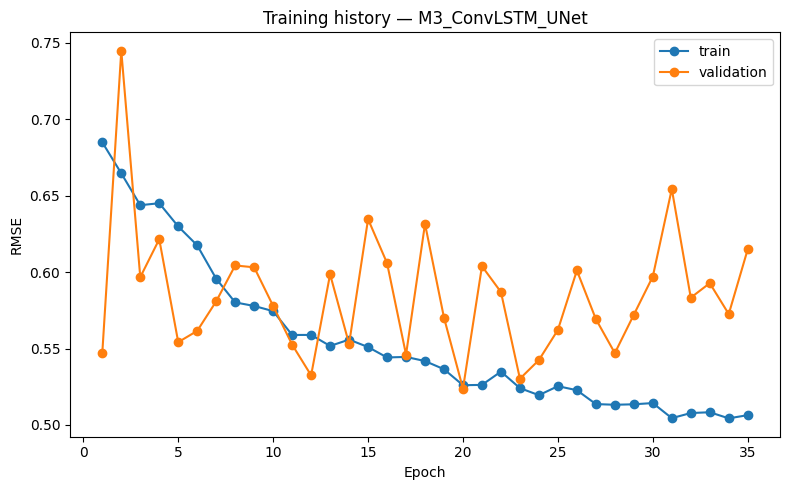

README guardado en: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M3_ConvLSTM_UNet/README_M3_ConvLSTM_UNet.md


3668

In [11]:

# ============================================================
# CELDA 11 — Resumen y limpieza de memoria
# ============================================================

split_df = result["split_eval"].copy()
year_df = result["year_eval"].copy()
history_df = result["history"].copy()

display(split_df)
display(year_df[year_df["split"] == "test"].sort_values("target_year"))

# Figura rápida: curvas RMSE train/validation.
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_rmse"], marker="o", label="train")
plt.plot(history_df["epoch"], history_df["val_rmse"], marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title(f"Training history — {CFG.model_key}")
plt.legend()
plt.tight_layout()
fig_path = OUTPUT_DIR / "figures" / f"08_history_rmse_{CFG.model_key}.png"
plt.savefig(fig_path, dpi=200)
plt.show()

readme = f"""# {CFG.model_key}

## Módulo 08 — entrenamiento independiente

Modelo: {CFG.model_description}

## Entrada

```text
{INPUT_DIR}
```

Modo de dataset:

```text
{CFG.dataset_mode}
```

Canales usados:

```text
{train_ds.X.shape[1]}
```

## Salidas principales

```text
checkpoints/best_{CFG.model_key}.pt
history/08_history_{CFG.model_key}.csv
evaluation/08_eval_by_split_{CFG.model_key}.csv
evaluation/08_eval_by_year_{CFG.model_key}.csv
figures/08_history_rmse_{CFG.model_key}.png
```

## Nota metodológica

Este notebook entrena un solo modelo para reducir consumo de RAM y evitar contaminación entre experimentos. La comparación final debe ejecutarse en `08F_compare_models.ipynb` leyendo los CSV exportados por cada entrenamiento.
"""
readme_path = OUTPUT_DIR / f"README_{CFG.model_key}.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme)
print("README guardado en:", readme_path)

# Limpieza explícita. Aun así se recomienda reiniciar entorno entre modelos.
import gc
try:
    del result
    torch.cuda.empty_cache()
except Exception:
    pass
gc.collect()
